# VGG Feature Extraction
A more sophisticated method to do clustering of in-plane images is to extract features using convlutional neural networks.

To extract features, we will download the pre-trained VGG model, take the feature layer, average pooling layer, and one fully-connected layer that outputs a 4096-dimensional vector. 

Reference: Simonyan, K., & Zisserman, A. (2015). Very Deep Convolutional Networks for Large-Scale Image Recognition. ArXiv:1409.1556 [Cs]. http://arxiv.org/abs/1409.1556


In [80]:
%load_ext autoreload
%autoreload 2

import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
from datetime import datetime, timedelta
from gui import *
import image_utils
from pathlib import Path
from IPython.display import HTML, Video
from SessionLoader import SessionLoader

# import nilearn as nl
from nilearn import image
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix

import nibabel as nib


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [142]:
# VGG 

import torch
from torch import optim, nn
from torchvision import models, transforms
from tqdm import tqdm
from torchvision.transforms import v2

class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super(FeatureExtractor, self).__init__()
                    # Extract VGG-16 Feature Layers
        self.features = list(model.features)
        self.features = nn.Sequential(*self.features)
                    # Extract VGG-16 Average Pooling Layer
        self.pooling = model.avgpool
                    # Convert the image into one-dimensional vector
        self.flatten = nn.Flatten()
                    # Extract the first part of fully-connected layer from VGG16
        self.fc = model.classifier[0]

    def forward(self, x):
        # It will take the input 'x' until it returns the feature vector called
        out = self.features(x)
        out = self.pooling(out)
        out = self.flatten(out)
        out = self.fc(out)
        return out

/Users/ewina/miniforge3/envs/Mangrove/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning:

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.

/Users/ewina/miniforge3/envs/Mangrove/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning:

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.



In [143]:
################################################
#   Apply VGG feature extraction on fUSI       #
################################################

def extract_features(fusi_data, model, device): 

      if fusi_data.ndim == 4: # if the data is 4D, take the first channel elevation = 0
            fusi_data = fusi_data[:,0]

      #  Transform the image, so it becomes readable with the model
      transform = v2.Compose([
            v2.ToImage(),
            v2.Resize((448, 448)),
            v2.Grayscale(num_output_channels=3),
            v2.ToDtype(torch.float32, scale=True),
      ])

      # Will contain the feature
      features = []
      # Iterate each image
      for i in tqdm(range(fusi_data.shape[-1])):
            # Read the file
            img = fusi_data[..., i]
            # Transform the image
            img = transform(img)
            # Reshape the image. PyTorch model reads 4-dimensional tensor
            # [batch_size, channels, width, height]
            img = img.reshape(1, 3, 448, 448)
            img = img.to(device)
            # We only extract features, so we don't need gradient
            with torch.no_grad():
                  # Extract the feature from the image
                  feature = model(img)
                  # Convert to NumPy Array, Reshape it, and save it to features variable
            features.append(feature.cpu().detach().numpy().reshape(-1))
      # Convert to NumPy Array
      features = np.array(features)
      return features

# Load NIFTI

In [175]:
#################################################################
#      Define data paths and choose output path location        #
#################################################################

save_output_on_local = True
base_path = '/Volumes/UCLA_collaboration/'
session_run = '2024-06-04/UCLA_005/speech_stimulation/acquisitions/seq-RF_5000000Hz_7a_3c_2rp_35Dmin_65Dmax_5el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops/power_doppler'
# define output path to save data, plots, and videos (default: /fUSI_corrected)
if save_output_on_local:
    output_path = Path.home() / "Downloads" / "Data" / session_run  # save to user defined location e.g. (/Downloads folder)
else:
    # default to /fUSI_corrected within acqusition sequence in base_path (ses.sequence_data_path)
    output_path = None

#################################################################
#          Loading paths and choose acquisition sequence        #
#################################################################

ses = SessionLoader(base_path + session_run, sequence=None, output_path=output_path)
if ses.sequence_folders is not None:
    ses.load_acquisition_directories( sequence_index=0 ) # switch between sequences if there are multiple (default: 0)

#################################################################
#                          Loading NIFTI                        #
#################################################################

filename = 'original.nii.gz'
fusi_data = ses.load_nifti(path_name=ses.output_path, filename=filename)

The log file does not exist.
The streams file does not exist.
The task event file does not exist.
The probe event file does not exist.
No sequence is found in the given base path.

Loaded power doppler images stored in NIFTI. Shape: (128, 1, 226, 555)
No metadata json file found.
No probe_events file found.


In [173]:
#################################################################
#                    Display Power Doppler movie                #
#################################################################
Video(output_path /'pd.mp4', embed=True)

Outlier frames more than 2000.0 from median:  []


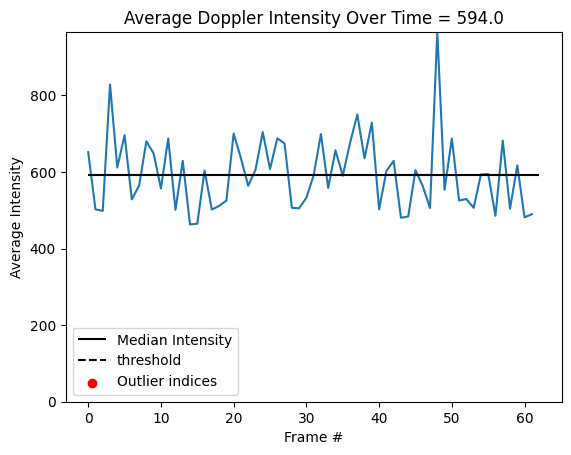

In [174]:
#################################################################
#             Display Doppler intensity time course             #
#################################################################
outlier_threshold = 2000

doppler_intensity_per_frame, outlier_intensity_frames, fig = \
    image_utils.plot_pd_intensity_over_time(fusi_data, 
                                            outlier_threshold=outlier_threshold)

# Apply VGG pretrain model

In [176]:
# Initialize the model
model = models.vgg16(pretrained=True)
new_model = FeatureExtractor(model)

# Change the device to GPU if available
device = torch.device('cuda:0' if torch.cuda.is_available() else "cpu")
new_model = new_model.to(device)
features = extract_features(fusi_data, new_model, device)

/Users/ewina/miniforge3/envs/Mangrove/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning:

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.

/Users/ewina/miniforge3/envs/Mangrove/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning:

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.

100%|██████████| 555/555 [07:33<00:00,  1.22it/s]


# Clustering with kmeans

In [150]:
n_clusters = 2

# Initialize the model
from sklearn.cluster import KMeans
model = KMeans(n_clusters=n_clusters, random_state=42)
# Fit the data into the model
model.fit(features)
# Extract the labels
labels = model.labels_

print(labels)
pred_labels,_ = image_utils.remap_cluster_to_labels(labels)
print(pred_labels)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0 -1]


In [148]:
from sklearn.decomposition import PCA
import image_utils

# normalize the data
features_norm = (features - features.mean(axis=0)) / features.std(axis=0)

##### PCA
pca_n_components = 2
pca=PCA(n_components=pca_n_components)

# Reduce number of dimension
lowd = pca.fit_transform(features_norm)

/Users/ewina/Downloads/Data/2024-06-13/UCLA_006/run-09


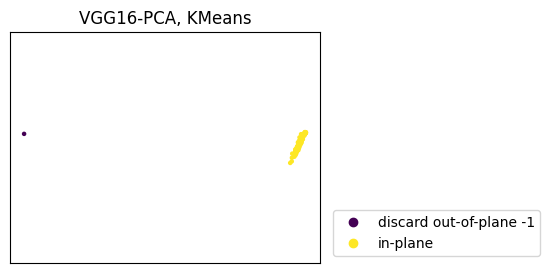

In [155]:
image_utils.plot_embedding(lowd, pred_labels, 'VGG16-PCA, KMeans')
plt.savefig(output_path / 'VGG16-PCA-KMeans.png', dpi=300, bbox_inches='tight')
print(output_path)